In [17]:
import numpy as np ; import matplotlib.pyplot as plt

def load_variables_to_dict(file_path):
    variables_dict = {}
    with open(file_path, 'r') as file:
        lines = file.readlines()
    for line in lines:
        if line.startswith('Variable'):
            parts = line.split(':')
            if len(parts) > 1:
                variable_info = parts[1].split('def =')
                if len(variable_info) > 1:
                    var_name = variable_info[0].split()[0].strip()
                    numerical_values = variable_info[1].split()
                    for value in numerical_values:
                        try:
                            num_value = float(value)
                            variables_dict[var_name.split(',')[0]] = num_value
                            break
                        except ValueError:
                            continue
    return variables_dict


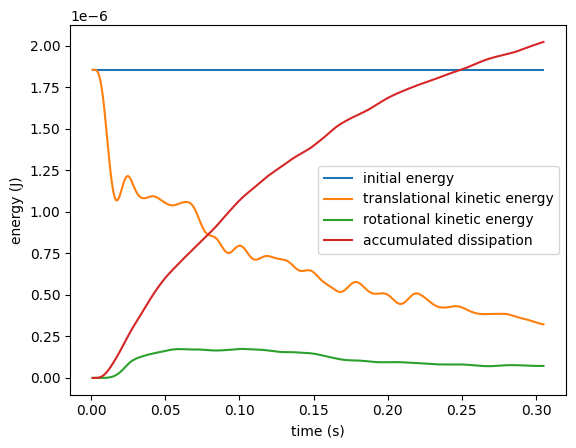

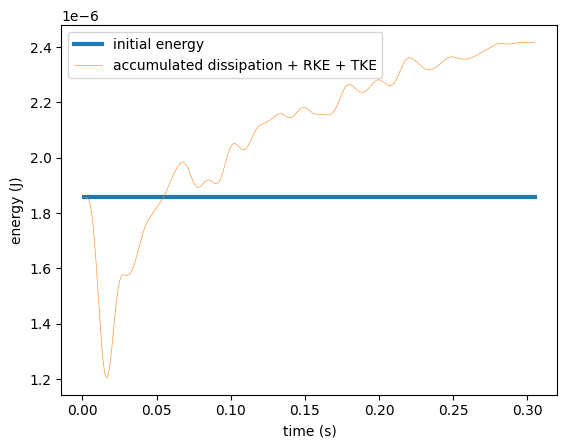

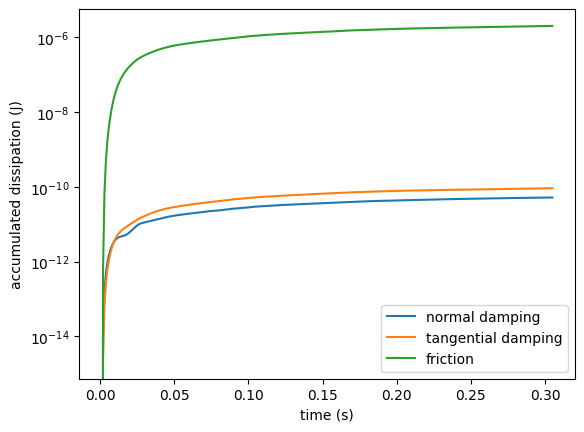

In [598]:

data = np.loadtxt('energy.dat', skiprows=1)
parameters = load_variables_to_dict('info')

time = data[:, 0].astype(int)*parameters['timeStep']
kin_eng = data[:, 1]
rotkin_eng = data[:, 2]
diss1 = data[:, 3]*parameters['avewindow']
diss2 = data[:, 4]*parameters['avewindow']
diss3 = data[:, 5]*parameters['avewindow']
total_diss = diss1+diss2+diss3

plt.figure()
plt.xlabel('time (s)'); plt.ylabel('energy (J)')
plt.plot(time, [kin_eng[0]]*len(time), label='initial energy')
plt.plot(time, kin_eng, label='translational kinetic energy')
plt.plot(time, rotkin_eng, label='rotational kinetic energy')
plt.plot(time, np.cumsum(total_diss), label='accumulated dissipation')
plt.legend()

plt.figure()
plt.xlabel('time (s)'); plt.ylabel('energy (J)')
plt.plot(time, [kin_eng[0]]*len(time), lw=3, label='initial energy')
plt.plot(time, np.cumsum(total_diss) + kin_eng + rotkin_eng, alpha=0.8, lw=0.5,
         label='accumulated dissipation + RKE + TKE')
plt.legend()

plt.figure()
plt.xlabel('time (s)'); plt.ylabel('accumulated dissipation (J)')
plt.plot(time, np.cumsum(diss1), label='normal damping')
plt.plot(time, np.cumsum(diss2), label='tangential damping')
plt.plot(time, np.cumsum(diss3), label='friction')
plt.yscale('log')
plt.legend()